# 1.- Acceder a los datos y prepararlos para su analisis. 

## Importacion de las librerias necesarias.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

## Importacion de los datos

In [135]:
visits_df = pd.read_csv('/datasets/visits_log_us.csv')
orders_df = pd.read_csv('/datasets/orders_log_us.csv')
costs_df = pd.read_csv('/datasets/costs_us.csv')

## Primer vistazo a los DataFrames

In [136]:
#DataFrame de visitas
print(visits_df.head())
print(visits_df.info())

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage

In [137]:
#Convertiremos las columnas "End Ts" y "Start Ts" a fechas
visits_df['End Ts'] = pd.to_datetime(visits_df['End Ts'])
visits_df['Start Ts'] = pd.to_datetime(visits_df['Start Ts'])
print(visits_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB
None


In [138]:
#Buscaremnos valores duplicados en el DataFrame visits_df
orders_df.duplicated().sum()


0

In [139]:
# DataFrame de ordenes
print(orders_df.head())
print(orders_df.info())

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None


In [140]:
#Buscamos valores duplicados en orders_df
orders_df.duplicated().sum()


0

In [141]:
#Revisamos los valores duplicados en orders_df
temp_orders_df = orders_df[orders_df.duplicated()]
temp_orders_df.head(40)

,Buy Ts,Revenue,Uid


In [142]:
temp_orders_df.tail(40)

,Buy Ts,Revenue,Uid


In [143]:
#Eliminamos los valores duplicados de orders_df, no parece haber patrones entre estos datos
orders_df.drop_duplicates(inplace=True)

In [144]:
orders_df.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [145]:
#Buscamos filas duplicadas en el DataFrame orders_df
orders_df.duplicated().sum()

0

In [146]:
#DataFrame de costos
print(costs_df.head())
print(costs_df.info())

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None


In [147]:
#Convertimos la columna 'dt' a formato de fecha
costs_df['dt'] = pd.to_datetime(costs_df['dt'])
print(costs_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB
None


In [148]:
#Buscando duplicados en el DataFrame costs_df
costs_df.duplicated().sum()

0

# 2.- Informes y calculo de métricas

## DataFrame visitas

### 2.1.1 ¿Cuántas personas lo usan cada día, semana y mes?

In [149]:
visits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


In [150]:
#Calculo de visitas por día
visitors_per_day = visits_df.groupby(visits_df['Start Ts'].dt.date)['Uid'].nunique().reset_index()
visitors_per_day.columns = ['date', 'visitors']
visitors_per_day.head()

,date,visitors
0,2017-06-01,605
1,2017-06-02,608
2,2017-06-03,445
3,2017-06-04,476
4,2017-06-05,820


In [151]:
#Promedio de personas que visitan por día
visitors_per_day_mean = '{:.2f}'.format(visitors_per_day['visitors'].mean())
print('Promedio de personas que hacen visitas diarias:', visitors_per_day_mean)

Promedio de personas que hacen visitas diarias: 907.99


In [152]:
#Calculo de visitas por semana
visitors_per_week = visits_df.groupby(visits_df['Start Ts'].dt.to_period('W'))['Uid'].nunique().reset_index()
visitors_per_week.columns = ['date_week', 'visitors']
visitors_per_week.head()


,date_week,visitors
0,2017-05-29/2017-06-04,2021
1,2017-06-05/2017-06-11,4129
2,2017-06-12/2017-06-18,2812
3,2017-06-19/2017-06-25,2878
4,2017-06-26/2017-07-02,3064


In [153]:
#Promedio de visitas por semana
visitors_per_week_mean = '{:.2f}'.format(visitors_per_week['visitors'].mean())
print('Promedio personas que visitan por semana:', visitors_per_week_mean)

Promedio personas que visitan por semana: 5716.25


In [154]:
#Promedio de visitas por mes
visitors_per_month = visits_df.groupby(visits_df['Start Ts'].dt.to_period('M'))['Uid'].nunique().reset_index()
visitors_per_month.columns = ['date_month','visitors_mean']
visitors_per_month.head()

,date_month,visitors_mean
0,2017-06,13259
1,2017-07,14183
2,2017-08,11631
3,2017-09,18975
4,2017-10,29692


In [155]:
#Promedio de visitas por mes
visitors_per_month_mean = '{:.2f}'.format(visitors_per_month['visitors_mean'].mean())
print('Promedio personas que visitan por mes:', visitors_per_month_mean)

Promedio personas que visitan por mes: 23228.42


### 2.1.2 Cantidad de sesiones por día

In [156]:
visits_per_day = visits_df.groupby(visits_df['Start Ts'].dt.date)['Uid'].count().reset_index()
visits_per_day.columns = ['date', 'total_visits']
visits_per_day.head()

,date,total_visits
0,2017-06-01,664
1,2017-06-02,658
2,2017-06-03,477
3,2017-06-04,510
4,2017-06-05,893


In [157]:
#Promedio de visitas por día
visits_per_day_mean = '{:.2f}'.format(visits_per_day['total_visits'].mean())
print('Promedio de visitas diarias:', visits_per_day_mean)

Promedio de visitas diarias: 987.36


## 2.1.3 Duracion de cada sesion

In [158]:
visits_df['session_time'] = visits_df['End Ts'] - visits_df['Start Ts']
visits_df.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_time
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,0 days 00:00:00


In [159]:
print('Tiempo promedio de la duracion de cada visita:', visits_df['session_time'].mean())

Tiempo promedio de la duracion de cada visita: 0 days 00:10:43.025687256


## 2.1.4 Frecuencia con la cual los usuarios vuelven a hacer una visita


In [160]:
#Obtenemos el mes de la primera visita para cada user
first_visit_user = visits_df.groupby('Uid')['Start Ts'].min().reset_index()
first_visit_user.columns = ['Uid', 'first_visit_date']
first_visit_user.head()

,Uid,first_visit_date
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00


In [161]:
#Añadimos esta columna del primer mes de visita al DataFrame visits_df
added_first_order_month = visits_df.merge(first_visit_user, on='Uid')
added_first_order_month.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_time,first_visit_date
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00,2017-12-20 17:20:00
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00,2018-02-19 16:53:00
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00,2017-07-01 01:54:00
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00,2018-03-09 20:05:00
4,desktop,2018-03-09 20:33:00,4,2018-03-09 20:05:00,16174680259334210214,0 days 00:28:00,2018-03-09 20:05:00


In [162]:
#Damos formato a la columna "first_visit_date" para visualizarla en formato de año y mes
added_first_order_month['first_visit_date'] = added_first_order_month['first_visit_date'].dt.to_period('M')
added_first_order_month.head()


,Device,End Ts,Source Id,Start Ts,Uid,session_time,first_visit_date
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00,2017-12
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00,2018-02
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00,2017-07
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00,2018-03
4,desktop,2018-03-09 20:33:00,4,2018-03-09 20:05:00,16174680259334210214,0 days 00:28:00,2018-03


In [163]:
#Añadimos el año y mes de la visita de cada cliente en la columna "order_month"
added_first_order_month['order_month'] = added_first_order_month['Start Ts'].dt.to_period('M')
added_first_order_month.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_time,first_visit_date,order_month
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00,2017-12,2017-12
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00,2018-02,2018-02
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00,2017-07,2017-07
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00,2018-03,2018-05
4,desktop,2018-03-09 20:33:00,4,2018-03-09 20:05:00,16174680259334210214,0 days 00:28:00,2018-03,2018-03


In [164]:
#Obtenemos la matriz de retencion entera de clientes que vuelven a visitar la pagina
absolute_visits = added_first_order_month.pivot_table(
    index = 'first_visit_date',
    columns= 'order_month',
    values = 'Uid',
    aggfunc = 'nunique'
)
absolute_visits

order_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05
first_visit_date,,,,,,,,,,,,
2017-06,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07,NaN,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0
2017-08,NaN,NaN,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0
2017-09,NaN,NaN,NaN,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0
2017-10,NaN,NaN,NaN,NaN,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0
2017-11,NaN,NaN,NaN,NaN,NaN,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0
2017-12,NaN,NaN,NaN,NaN,NaN,NaN,25268.0,1410.0,960.0,786.0,512.0,481.0
2018-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22624.0,1351.0,890.0,565.0,458.0
2018-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22197.0,1267.0,565.0,446.0


In [165]:
#Obtendremos la matriz de retencion porcentual
retention = absolute_visits.div(absolute_visits.apply(lambda row: row.dropna().iloc[0], axis=1), axis=0)
retention

order_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05
first_visit_date,,,,,,,,,,,,
2017-06,1.0,0.078664,0.053775,0.061392,0.068557,0.071423,0.061015,0.057772,0.052342,0.050833,0.040652,0.044951
2017-07,NaN,1.000000,0.056088,0.051294,0.056164,0.058219,0.048174,0.045358,0.045738,0.038813,0.028615,0.027473
2017-08,NaN,NaN,1.000000,0.076908,0.062862,0.062764,0.050093,0.044004,0.036342,0.039485,0.027895,0.026029
2017-09,NaN,NaN,NaN,1.000000,0.085489,0.069205,0.050706,0.039392,0.037835,0.035860,0.024186,0.022809
2017-10,NaN,NaN,NaN,NaN,1.000000,0.078608,0.052239,0.038958,0.034261,0.032221,0.021365,0.020364
2017-11,NaN,NaN,NaN,NaN,NaN,1.000000,0.078281,0.044113,0.038682,0.033727,0.023415,0.021800
2017-12,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.055802,0.037993,0.031107,0.020263,0.019036
2018-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.059715,0.039339,0.024973,0.020244
2018-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.057080,0.025454,0.020093


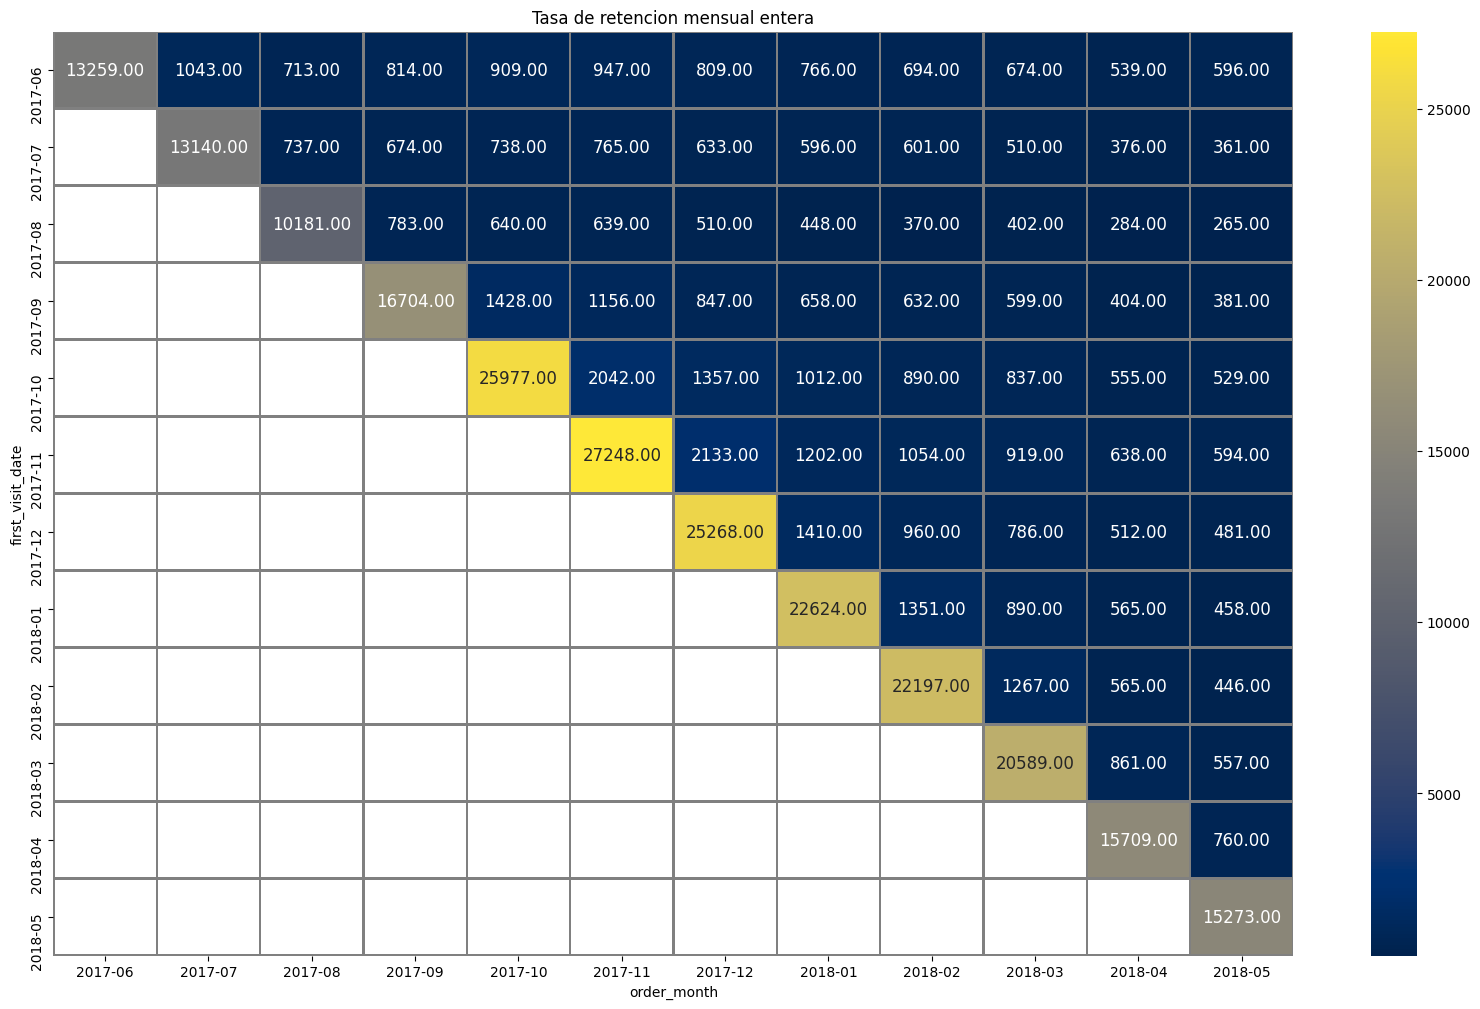

In [166]:
#Heatmap de la matriz de retencion entera

plt.figure(figsize= (20,12))
plt.title('Tasa de retencion mensual entera')

sns.heatmap(
    data= absolute_visits,
    annot= True,
    fmt='.2f',
    linewidths=1,
    linecolor='gray',
    annot_kws={'size':12},
    cbar=True,
    cmap='cividis'
)



plt.show()


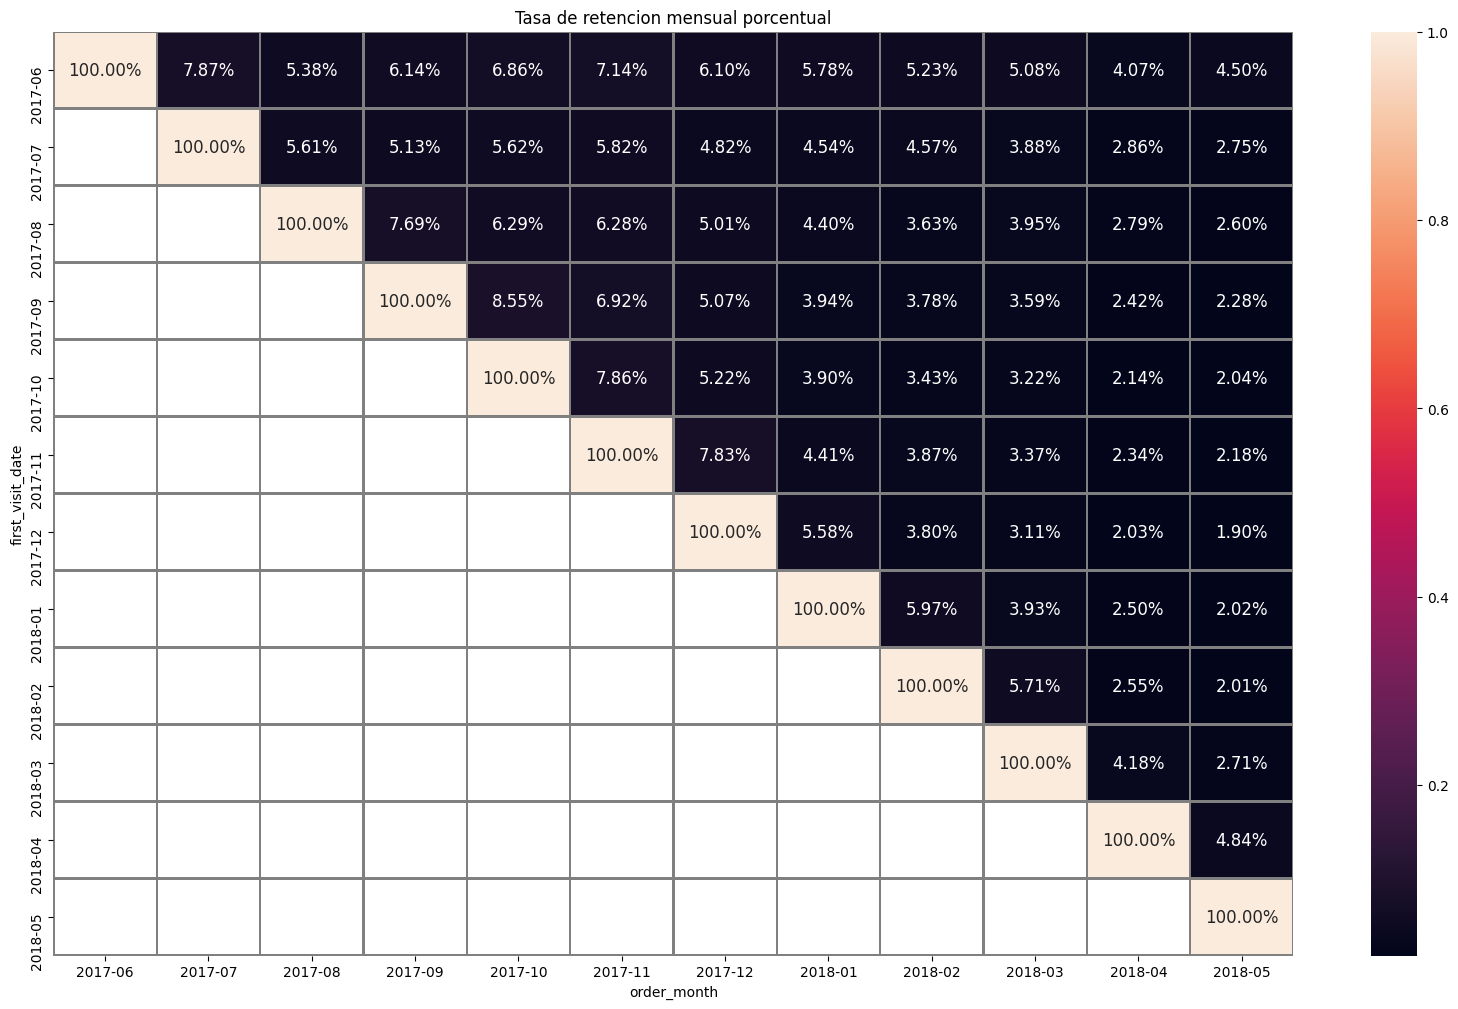

In [167]:
#Heatmap de la matriz de retencion porcentual
plt.figure(figsize= (20,12))
plt.title('Tasa de retencion mensual porcentual')

sns.heatmap(
    data= retention,
    annot= True,
    fmt='.2%',
    linewidths=1,
    linecolor='gray',
    annot_kws={'size':12},
    cbar=True,
    cmap='rocket'
)



plt.show()


In [168]:
'''
Podemos observar porcentajes relaticvamente bajos en la tasa de retencion mensual (menores al 10%, algunos incluso menores al 5%),
Aunque esto pudiera tambien a picos muy altos en la captacion de nuevos usuarios.
'''

'\nPodemos observar porcentajes relaticvamente bajos en la tasa de retencion mensual (menores al 10%, algunos incluso menores al 5%),\nAunque esto pudiera tambien a picos muy altos en la captacion de nuevos usuarios.\n'

# 2.2 Analisis de ventas

## 2.2.1 ¿Cuando comienza la gente a comprar?

In [169]:
#Obtendremos la fecha de la primera visita y la fecha de la primera compra de cada usuario
#DF con la fecha de la primera visita por usuario
first_visit_user.head()

,Uid,first_visit_date
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00


In [170]:
orders_df.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [171]:
#Primera compra de cada usuario
first_order_month = orders_df.groupby('Uid')['Buy Ts'].min()
first_order_month.rename('first_order_month')

Uid
313578113262317         2018-01-03 21:51:00
1575281904278712        2017-06-03 10:13:00
2429014661409475        2017-10-11 18:33:00
2464366381792757        2018-01-28 15:54:00
2551852515556206        2017-11-24 10:14:00
                               ...         
18445147675727495770    2017-11-24 09:03:00
18445407535914413204    2017-09-22 23:55:00
18445601152732270159    2018-03-26 22:54:00
18446156210226471712    2018-02-18 19:34:00
18446167067214817906    2017-10-17 10:16:00
Name: first_order_month, Length: 36523, dtype: object

In [172]:
#Unimos los DF y renombramos las columans
convertion = first_visit_user.merge(first_order_month, on='Uid')
convertion.columns = ['Uid', 'first_visit', 'first_order']
convertion['first_order']=pd.to_datetime(convertion['first_order'])
convertion.head()

,Uid,first_visit,first_order
0,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00
2,2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00
3,2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00


In [ ]:

#Nos aseguramos de que todas las ordenes se hayan efectuado el mismo dia, o dias despues de la primera visita
okay_orders = convertion.query("first_visit == first_order or first_visit <= first_order")
okay_orders.info()
#Vemos que no tenemos problemas con las fechas, podemos continuar con el analisis

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36523 entries, 0 to 36522
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Uid          36523 non-null  uint64        
 1   first_visit  36523 non-null  datetime64[ns]
 2   first_order  36523 non-null  datetime64[ns]
dtypes: datetime64[ns](2), uint64(1)
memory usage: 1.1 MB


In [ ]:
#Crearemos una columna con la diferencia de dias entre la primer visita y la primer orden
convertion['days_to_first_order'] = (convertion['first_order'] - convertion['first_visit']).dt.days
convertion.head()

,Uid,first_visit,first_order,days_to_first_order
0,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00,0
2,2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00,0
3,2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00,0
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00,0


In [175]:
#Listado del tiempo que tardan los clientes en realizar un pedido.
convertion.loc[convertion['days_to_first_order'] > 30, 'category'] = 'Mas de un mes'
convertion.loc[convertion['days_to_first_order'] <=  30, 'category'] = 'Hasta un mes'
convertion.loc[convertion['days_to_first_order'] <=  7, 'category'] = 'Hasta una semana'
convertion.loc[convertion['days_to_first_order'] == 0, 'category'] = '0 días'

convertion.head(20)

,Uid,first_visit,first_order,days_to_first_order,category
0,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106,Mas de un mes
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00,0,0 días
2,2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00,0,0 días
3,2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00,0,0 días
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00,0,0 días
5,3077748354309989,2018-03-03 12:08:00,2018-03-03 12:33:00,0,0 días
6,3605148382144603,2017-08-15 21:54:00,2017-09-21 20:56:00,36,Mas de un mes
7,3753586865891862,2018-03-03 13:47:00,2018-03-03 13:50:00,0,0 días
8,4808417689019433,2018-01-09 23:10:00,2018-01-09 23:32:00,0,0 días
9,4992223027560440,2018-04-04 13:54:00,2018-04-04 13:54:00,0,0 días


In [176]:
#Listado del tiempo que tardan los clientes en realizar un pedido.
category_convertion = convertion.groupby('category')['Uid'].count().reset_index()
category_convertion.columns = ['convertion', 'qty']
category_convertion = category_convertion.sort_values(by='qty', ascending=False)
category_convertion.head()

,convertion,qty
0,0 días,26363
3,Mas de un mes,4902
2,Hasta una semana,3080
1,Hasta un mes,2178


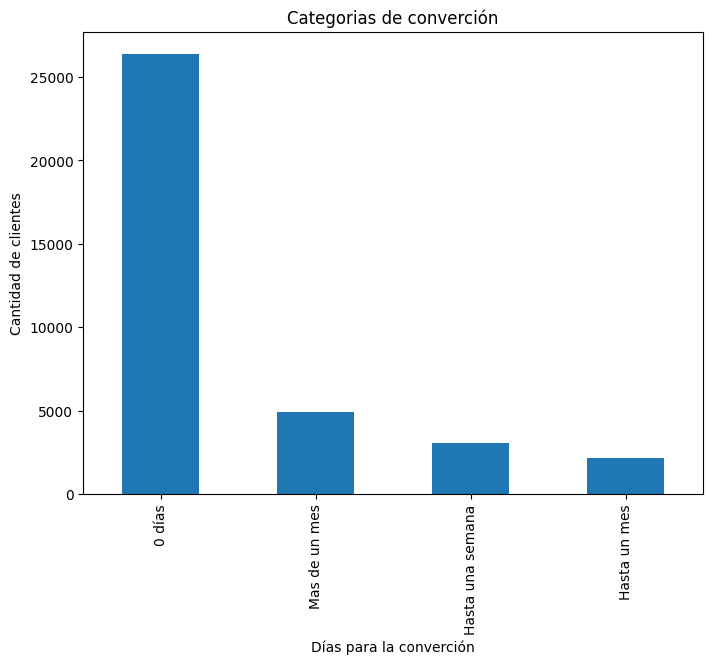

In [177]:
category_convertion.plot(
    kind='bar',
    title='Categorias de converción',
    x='convertion',
    y='qty',
    xlabel = 'Días para la converción',
    ylabel='Cantidad de clientes',
    figsize=(8,6),
    legend=False
)

plt.show()

In [178]:
'''
Podemos observar que en gran medida, la mayoria de los clientes hacen su primer compra en el día 0 despues de su primera visita.
'''

'\nPodemos observar que en gran medida, la mayoria de los clientes hacen su primer compra en el día 0 despues de su primera visita.\n'

### 2.2.1 ¿Cuantos pedidos hacen durante un periodo de tiempo dado?

In [180]:
#Calcularemos el volumen de pedidos a partir de la convercion por periodo mensual. 
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.5+ MB


In [181]:
orders_df['Buy Ts'] = pd.to_datetime(orders_df['Buy Ts'])
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.5 MB


In [182]:
#Obtenemos la primera fecha de compra de cada usuario
first_purchase = orders_df.groupby('Uid')['Buy Ts'].min()
first_purchase.name = 'first_purchase_date'
orders_cohorts = orders_df.merge(first_purchase, on='Uid')
orders_cohorts.head()

,Buy Ts,Revenue,Uid,first_purchase_date
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00


In [183]:
#Añadimos el mes de cada uno de los pedidos realizados por los usuarios
orders_cohorts['purchase_month'] = pd.to_datetime(orders_cohorts['Buy Ts']).dt.to_period('M')
orders_cohorts['first_purchase_month'] = pd.to_datetime(orders_cohorts['first_purchase_date']).dt.to_period('M')
orders_cohorts.head()

,Buy Ts,Revenue,Uid,first_purchase_date,purchase_month,first_purchase_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06,2017-06


In [184]:
orders_cohorts.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50415 entries, 0 to 50414
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Buy Ts                50415 non-null  datetime64[ns]
 1   Revenue               50415 non-null  float64       
 2   Uid                   50415 non-null  uint64        
 3   first_purchase_date   50415 non-null  datetime64[ns]
 4   purchase_month        50415 non-null  period[M]     
 5   first_purchase_month  50415 non-null  period[M]     
dtypes: datetime64[ns](2), float64(1), period[M](2), uint64(1)
memory usage: 2.7 MB


In [185]:
#Calculamos el tiempo transcurrido entre la primera compra y la fecha actual
orders_cohorts['cohort_lifetime'] = (orders_cohorts['Buy Ts'] - orders_cohorts['first_purchase_date']) / np.timedelta64(1, 'M')
orders_cohorts['cohort_lifetime'] = orders_cohorts['cohort_lifetime'].round().astype(int)
orders_cohorts.head()


,Buy Ts,Revenue,Uid,first_purchase_date,purchase_month,first_purchase_month,cohort_lifetime
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06,2017-06,0
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06,2017-06,0
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06,2017-06,0
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06,2017-06,0
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06,2017-06,0


In [187]:
orders_matrix = orders_cohorts.pivot_table(
    index='first_purchase_month',
    columns='cohort_lifetime',
    values='Buy Ts',
    aggfunc = 'count'
)
orders_matrix

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11,12
first_purchase_month,,,,,,,,,,,,,
2017-06,2355.0,147.0,152.0,236.0,278.0,204.0,276.0,197.0,211.0,174.0,110.0,62.0,36.0
2017-07,2190.0,92.0,113.0,105.0,72.0,67.0,76.0,60.0,51.0,27.0,44.0,13.0,NaN
2017-08,1562.0,98.0,98.0,88.0,66.0,60.0,72.0,58.0,52.0,34.0,NaN,NaN,NaN
2017-09,2961.0,196.0,163.0,148.0,80.0,112.0,95.0,59.0,55.0,9.0,NaN,NaN,NaN
2017-10,4982.0,274.0,182.0,129.0,125.0,94.0,88.0,94.0,37.0,NaN,NaN,NaN,NaN
2017-11,4951.0,259.0,220.0,180.0,129.0,64.0,77.0,20.0,NaN,NaN,NaN,NaN,NaN
2017-12,5062.0,242.0,214.0,181.0,81.0,98.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,3807.0,211.0,149.0,75.0,59.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,4102.0,222.0,83.0,57.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


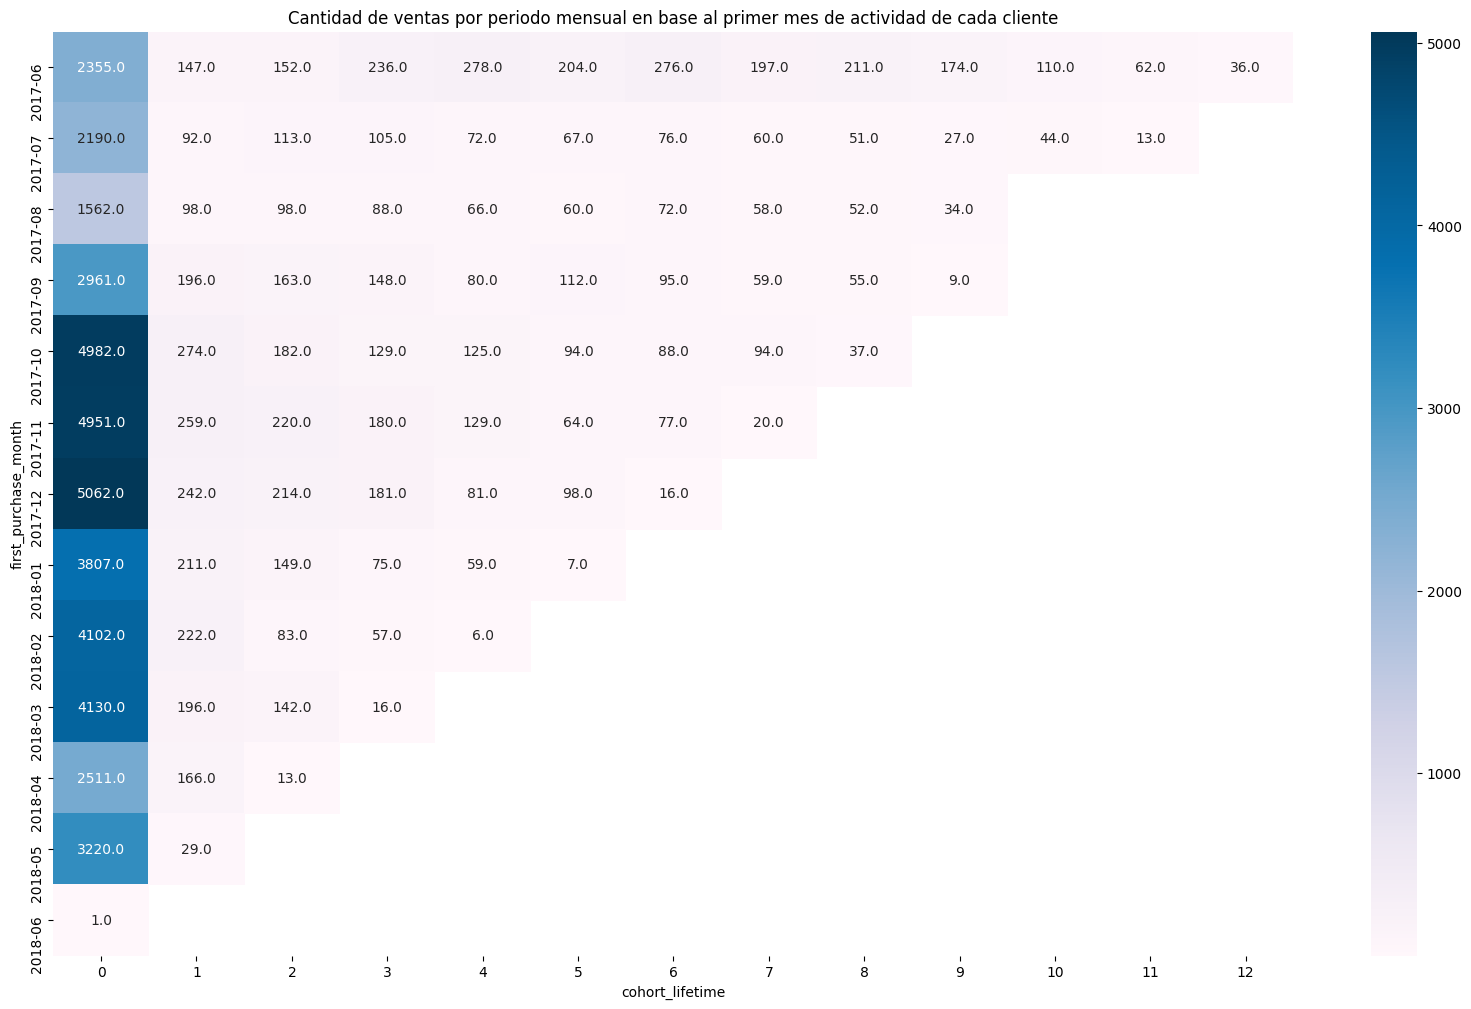

In [188]:

plt.figure(figsize = (20,12))
plt.title('Cantidad de ventas por periodo mensual en base al primer mes de actividad de cada cliente')

sns.heatmap(
    data= orders_matrix,
    annot=True,
    fmt='',
    linecolor='black',
    annot_kws={'size':10},
    cbar=True,
    cmap='PuBu'
)

plt.show()


### 2.2.3 ¿Cuál es el tamaño promedio de compra?

In [189]:
#Obtendremos el promedio del costo de la compra de manera mensual y por cohorte

purchase_mean = orders_cohorts.pivot_table(
    index='first_purchase_month',
    columns='cohort_lifetime',
    values='Revenue',
    aggfunc = 'mean'
)
purchase_mean


cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11,12
first_purchase_month,,,,,,,,,,,,,
2017-06,4.084964,5.332653,5.073355,7.359703,7.963094,7.095245,6.564493,5.651421,6.920711,7.339425,10.605727,7.141935,5.183333
2017-07,5.293269,6.757391,10.101770,6.632667,4.918750,3.473284,3.238816,5.038500,6.766471,9.978148,4.755455,8.999231,NaN
2017-08,4.669590,7.490714,5.981122,8.095909,6.865758,6.426333,5.922361,6.932759,7.873462,5.971471,NaN,NaN,NaN
2017-09,5.015535,12.862908,15.526503,61.491554,19.574375,16.760179,8.865158,14.786441,6.883636,15.148889,NaN,NaN,NaN
2017-10,4.405853,7.333504,5.366538,4.887829,5.818000,4.484468,3.877500,5.051915,1.945405,NaN,NaN,NaN,NaN
2017-11,4.315476,5.030232,4.933409,5.716167,4.835039,3.985625,4.254675,5.478500,NaN,NaN,NaN,NaN,NaN
2017-12,4.088528,4.764504,18.880607,26.122983,16.639383,14.936633,3.519375,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,3.677192,5.009289,7.107181,4.740933,2.965424,2.514286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,3.695992,4.781802,3.277590,4.105263,3.656667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


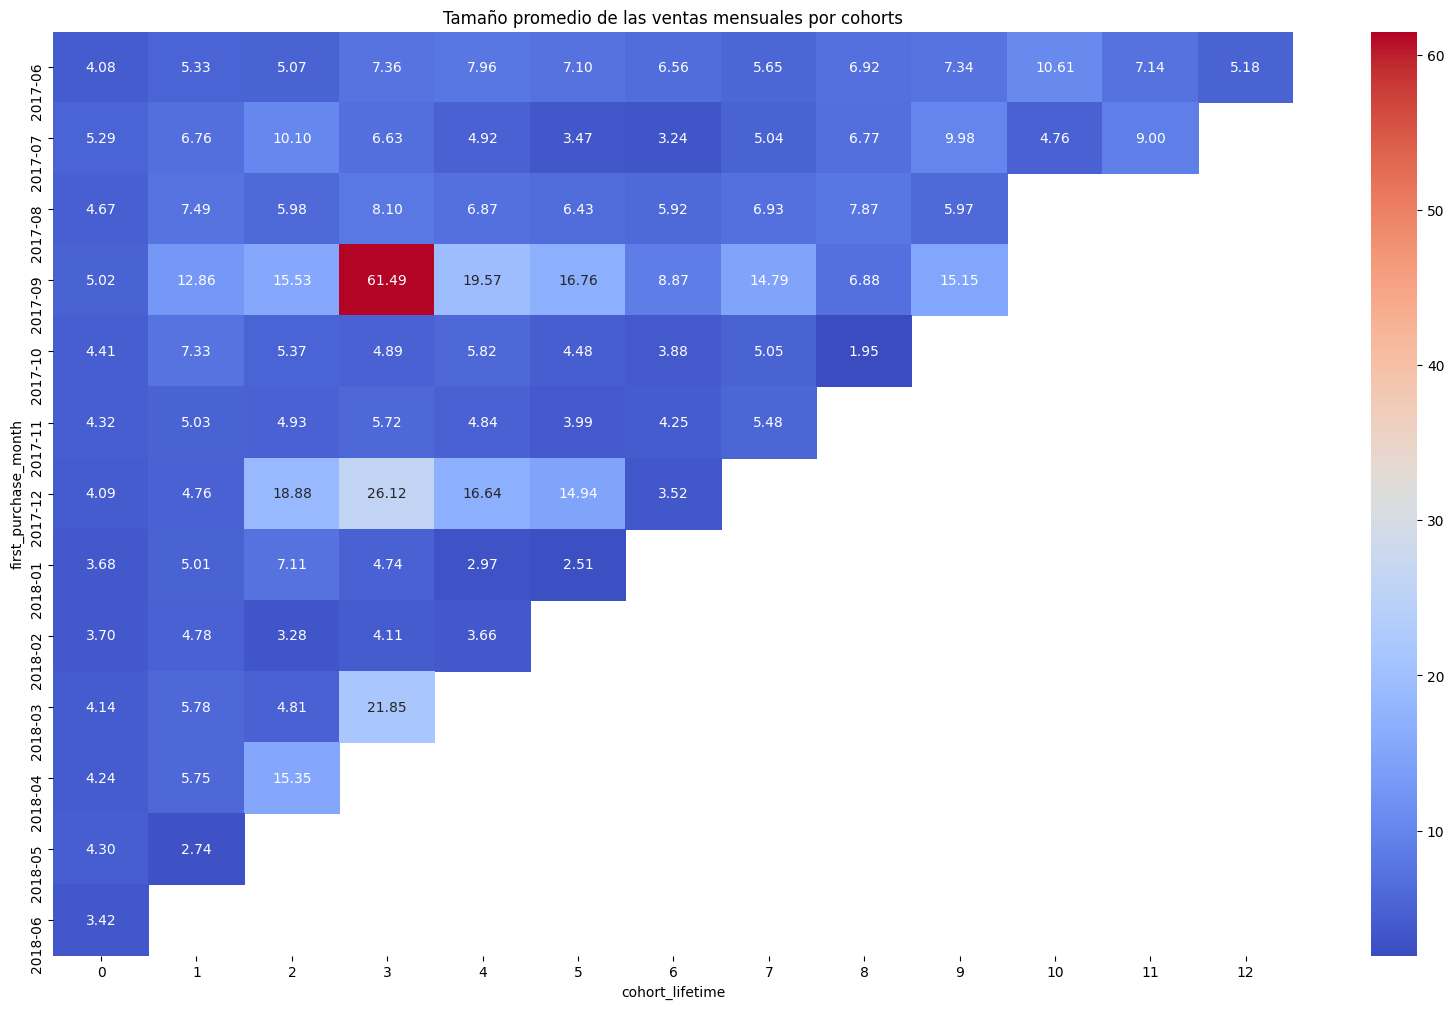

In [190]:

plt.figure(figsize = (20,12))
plt.title('Tamaño promedio de las ventas mensuales por cohorts')

sns.heatmap(
    data= purchase_mean,
    annot=True,
    fmt='.2f',
    linecolor='black',
    annot_kws={'size':10},
    cbar=True,
    cmap="coolwarm"
)

plt.show()



In [191]:
ltv = orders_cohorts.pivot_table(
    index = 'first_purchase_month',
    columns = 'cohort_lifetime',
    values = 'Revenue',
    aggfunc= 'sum'
)
ltv

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11,12
first_purchase_month,,,,,,,,,,,,,
2017-06,9620.09,783.90,771.15,1736.89,2213.74,1447.43,1811.80,1113.33,1460.27,1277.06,1166.63,442.80,186.6
2017-07,11592.26,621.68,1141.50,696.43,354.15,232.71,246.15,302.31,345.09,269.41,209.24,116.99,NaN
2017-08,7293.90,734.09,586.15,712.44,453.14,385.58,426.41,402.10,409.42,203.03,NaN,NaN,NaN
2017-09,14851.00,2521.13,2530.82,9100.75,1565.95,1877.14,842.19,872.40,378.60,136.34,NaN,NaN,NaN
2017-10,21949.96,2009.38,976.71,630.53,727.25,421.54,341.22,474.88,71.98,NaN,NaN,NaN,NaN
2017-11,21365.92,1302.83,1085.35,1028.91,623.72,255.08,327.61,109.57,NaN,NaN,NaN,NaN,NaN
2017-12,20696.13,1153.01,4040.45,4728.26,1347.79,1463.79,56.31,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,13999.07,1056.96,1058.97,355.57,174.96,17.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,15160.96,1061.56,272.04,234.00,21.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


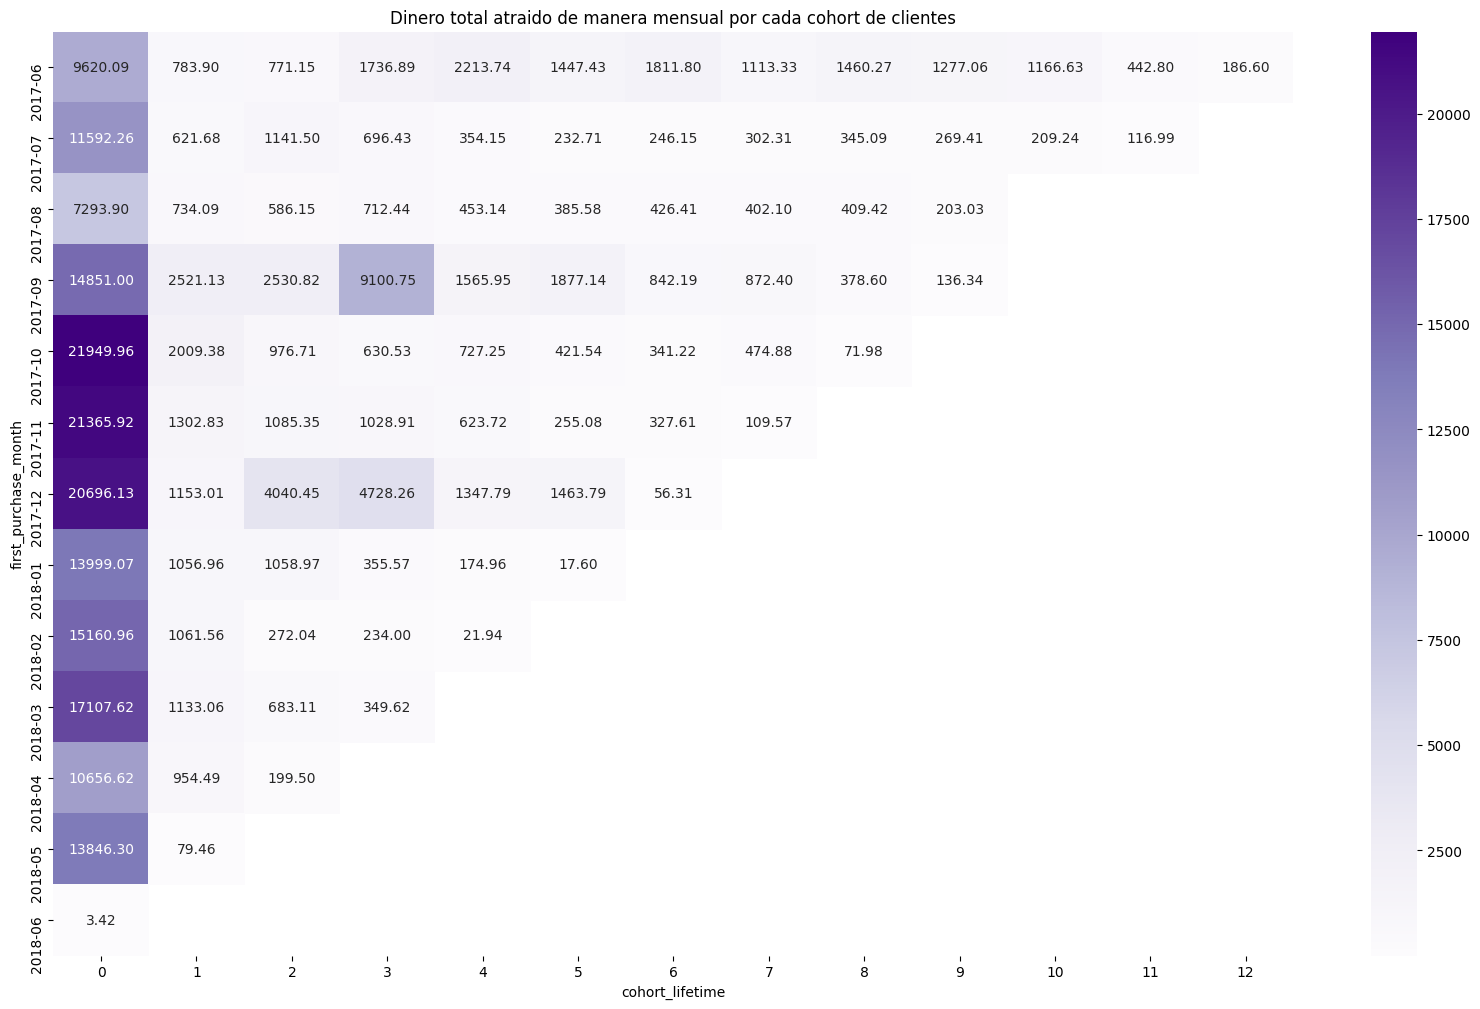

In [192]:
plt.figure(figsize = (20,12))
plt.title('Dinero total atraido de manera mensual por cada cohort de clientes')

sns.heatmap(
    data= ltv,
    annot=True,
    fmt='.2f',
    linecolor='black',
    annot_kws={'size':10},
    cbar=True,
    cmap="Purples"
)

plt.show()


### 2.3.1 ¿Cuanto dinero se gastó?

In [193]:
#Trabajaremos con el DataFrame que contiene los costos de las fuentes de anuncios
costs_df.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [194]:
#Añadimos la primera fecha de registro de cada fuente en un nuevo DataFrame llamado cohorts_costs
first_activity_log = costs_df.groupby('source_id')['dt'].min().reset_index()
first_activity_log.columns = ['source_id', 'first_activity_date']
cohorts_costs = costs_df.merge(first_activity_log, on='source_id')
cohorts_costs.head()

,source_id,dt,costs,first_activity_date
0,1,2017-06-01,75.20,2017-06-01
1,1,2017-06-02,62.25,2017-06-01
2,1,2017-06-03,36.53,2017-06-01
3,1,2017-06-04,55.00,2017-06-01
4,1,2017-06-05,57.08,2017-06-01


In [195]:
#Añadimos una columna con el primer mes de actividad
cohorts_costs['first_activity_month'] = cohorts_costs['first_activity_date'].dt.to_period('M')
cohorts_costs.head()

,source_id,dt,costs,first_activity_date,first_activity_month
0,1,2017-06-01,75.20,2017-06-01,2017-06
1,1,2017-06-02,62.25,2017-06-01,2017-06
2,1,2017-06-03,36.53,2017-06-01,2017-06
3,1,2017-06-04,55.00,2017-06-01,2017-06
4,1,2017-06-05,57.08,2017-06-01,2017-06


In [196]:
#Calculamos el tiempo de vida de cada cohorte
cohorts_costs['cohort_lifetime'] = (cohorts_costs['dt'] - cohorts_costs['first_activity_date'])/np.timedelta64(1, 'M')
cohorts_costs['cohort_lifetime'] = cohorts_costs['cohort_lifetime'].round().astype(int)
cohorts_costs.head()

,source_id,dt,costs,first_activity_date,first_activity_month,cohort_lifetime
0,1,2017-06-01,75.20,2017-06-01,2017-06,0
1,1,2017-06-02,62.25,2017-06-01,2017-06,0
2,1,2017-06-03,36.53,2017-06-01,2017-06,0
3,1,2017-06-04,55.00,2017-06-01,2017-06,0
4,1,2017-06-05,57.08,2017-06-01,2017-06,0


In [197]:
#Creamos la matriz con el total de los gastos mensuales de cada una de las fuentes
cohorts_costs_matrix = cohorts_costs.pivot_table(
    index='source_id',
    columns='cohort_lifetime',
    values='costs',
    aggfunc='sum'
)
cohorts_costs_matrix

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11,12
source_id,,,,,,,,,,,,,
1,710.40,980.90,939.37,1138.70,1972.45,2320.88,2517.61,2176.89,2292.74,2112.88,1479.09,1418.37,772.99
2,1337.96,2363.44,1890.28,2238.60,4194.17,4681.68,5544.23,4337.15,4474.39,4260.56,3351.43,2740.27,1391.88
3,4731.06,7491.77,5894.61,8090.71,13373.19,14660.39,18828.48,14808.72,15360.45,14197.91,9805.76,9169.92,4908.66
4,1935.77,3200.83,3403.21,4311.86,5242.62,6743.50,6983.21,5397.62,6543.76,6546.72,4714.59,3958.70,2091.21
5,1567.32,2674.24,2357.22,2845.58,4930.76,5825.99,6530.37,5552.74,5364.86,4876.30,3679.87,3522.72,2029.13
9,164.79,299.12,255.39,298.18,517.92,635.87,707.50,598.43,574.09,514.41,405.59,363.94,182.26
10,200.52,302.48,236.55,319.78,595.75,681.36,774.96,604.58,599.00,486.88,407.82,395.49,217.32


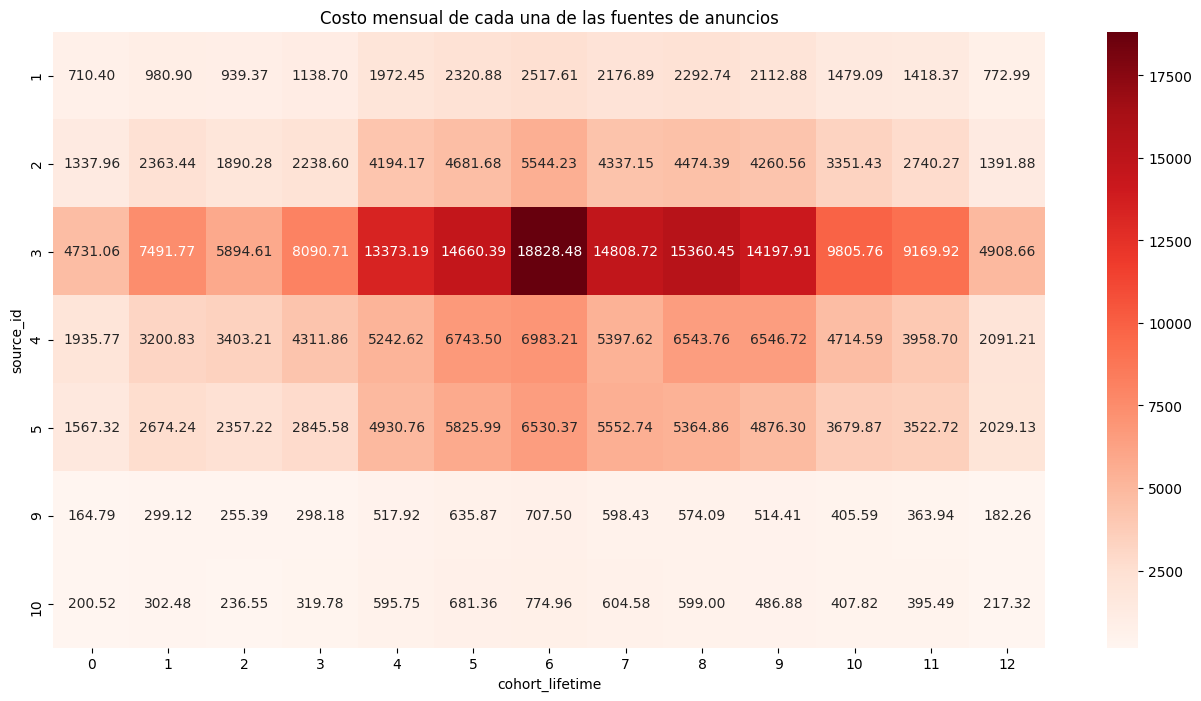

In [198]:

#Heatmap del costo de cada una de las fuentes
plt.figure(figsize = (16, 8))
plt.title('Costo mensual de cada una de las fuentes de anuncios')

sns.heatmap(
    data=cohorts_costs_matrix,
    annot=True,
    fmt='.2f',
    linecolor='black',
    annot_kws={'size':10},
    cbar=True,
    cmap="Reds"
    
)
plt.show()


In [199]:
'''
Podemos observar que la fuente de adquisicon donde mas se invierte dinero es en la fuente número 3
'''

'\nPodemos observar que la fuente de adquisicon donde mas se invierte dinero es en la fuente número 3\n'

### 2.3.2 ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

In [200]:
#Obtenemos el total gastado para cada una de las fuentes
source_costs = cohorts_costs.groupby('source_id')['costs'].sum()
source_costs.name= 'total_cost'
source_costs.head()

source_id
1     20833.27
2     42806.04
3    141321.63
4     61073.60
5     51757.10
Name: total_cost, dtype: float64

In [201]:
source_costs.reset_index().sort_values(by='total_cost', ascending=False)

,source_id,total_cost
2,3,141321.63
3,4,61073.60
4,5,51757.10
1,2,42806.04
0,1,20833.27
6,10,5822.49
5,9,5517.49


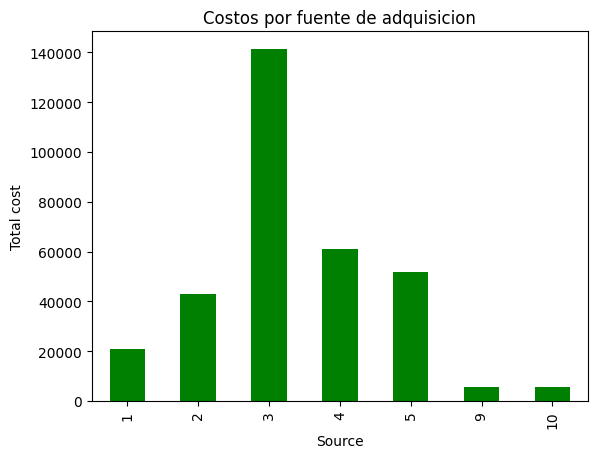

In [202]:
source_costs.plot(
    kind='bar',
    x='source_id',
    y='total_cost',
    xlabel='Source',
    ylabel='Total cost',
    color='green',
    title='Costos por fuente de adquisicion'
)
plt.show()

### 2.3.3  ¿Cuán rentables eran las inversiones? (ROMI)

## Calculo del ROMI por fuente de marketing

In [203]:
#Para esto, obtendremos un DataFrame que contenga informacion del dispositivo desde el cual se hace la compra, la fuente de marketing y el revenue de la orden
#Usaremos los dataframes visits_df y orders_df para despues compararlo con el DataFrame de cohorts_costs
visits_df.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_time
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,0 days 00:00:00


In [204]:
#Vamos a filtrar el DataFrame visits_df, obteniendo unicamente las visitas en las que se realizó una compra

In [205]:
#Eliminamos la columna de 'session_time' la cual no será reelevante para este analisis. 
filtered_visits_df = visits_df.drop('session_time', axis=1)
filtered_visits_df.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [206]:
filtered_visits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


In [207]:
orders_df.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [208]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.5 MB


In [209]:
#unimos los dataframes orders_df y filtered_visits_df
temp_df = filtered_visits_df.merge(orders_df, on='Uid')
temp_df.head(20)

,Device,End Ts,Source Id,Start Ts,Uid,Buy Ts,Revenue
0,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-03-09 20:25:00,2.33
1,desktop,2018-03-09 20:33:00,4,2018-03-09 20:05:00,16174680259334210214,2018-03-09 20:25:00,2.33
2,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-09-04 12:46:00,2.44
3,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-10-28 00:01:00,1.53
4,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-10-28 19:16:00,1.53
5,desktop,2017-10-27 16:02:00,3,2017-10-27 15:20:00,16007536194108375387,2017-09-04 12:46:00,2.44
6,desktop,2017-10-27 16:02:00,3,2017-10-27 15:20:00,16007536194108375387,2017-10-28 00:01:00,1.53
7,desktop,2017-10-27 16:02:00,3,2017-10-27 15:20:00,16007536194108375387,2017-10-28 19:16:00,1.53
8,desktop,2017-09-04 17:56:00,4,2017-09-04 17:37:00,16007536194108375387,2017-09-04 12:46:00,2.44
9,desktop,2017-09-04 17:56:00,4,2017-09-04 17:37:00,16007536194108375387,2017-10-28 00:01:00,1.53


In [210]:
#Revisamos por duplicados generados
temp_df.duplicated().sum()


0

In [211]:
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 761807 entries, 0 to 761806
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     761807 non-null  object        
 1   End Ts     761807 non-null  datetime64[ns]
 2   Source Id  761807 non-null  int64         
 3   Start Ts   761807 non-null  datetime64[ns]
 4   Uid        761807 non-null  uint64        
 5   Buy Ts     761807 non-null  datetime64[ns]
 6   Revenue    761807 non-null  float64       
dtypes: datetime64[ns](3), float64(1), int64(1), object(1), uint64(1)
memory usage: 46.5+ MB


In [ ]:
#Filtramos unicamente las visitas que representan una venta
complete_df = temp_df[(temp_df['Buy Ts'] >= temp_df['Start Ts']) & ((temp_df['Buy Ts'] <= temp_df['End Ts']))]
#complete_df = temp_df[temp_df['Buy Ts'].between(temp_df['Start Ts'], temp_df['End Ts'])]
complete_df.head(20)

,Device,End Ts,Source Id,Start Ts,Uid,Buy Ts,Revenue
1,desktop,2018-03-09 20:33:00,4,2018-03-09 20:05:00,16174680259334210214,2018-03-09 20:25:00,2.33
12,desktop,2017-10-28 00:04:00,3,2017-10-27 23:56:00,16007536194108375387,2017-10-28 00:01:00,1.53
29,desktop,2017-09-04 12:51:00,3,2017-09-04 12:44:00,16007536194108375387,2017-09-04 12:46:00,2.44
258,desktop,2018-03-06 14:21:00,2,2018-03-06 14:20:00,8056418121947262981,2018-03-06 14:21:00,3.05
797,desktop,2017-10-28 14:37:00,2,2017-10-28 14:29:00,8056418121947262981,2017-10-28 14:32:00,4.28
1602,desktop,2017-06-26 09:16:00,1,2017-06-26 08:13:00,8056418121947262981,2017-06-26 09:14:00,3.67
2748,desktop,2018-02-16 17:47:00,1,2018-02-16 17:29:00,8056418121947262981,2018-02-16 17:42:00,27.50
3027,desktop,2017-09-08 01:13:00,2,2017-09-08 00:03:00,8056418121947262981,2017-09-08 01:01:00,42.78
3294,desktop,2017-12-01 12:46:00,1,2017-12-01 12:00:00,8056418121947262981,2017-12-01 12:43:00,19.55
3942,desktop,2018-03-08 15:29:00,9,2018-03-08 13:45:00,8056418121947262981,2018-03-08 15:26:00,4.89


In [214]:
complete_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 35927 entries, 1 to 761806
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Device     35927 non-null  object        
 1   End Ts     35927 non-null  datetime64[ns]
 2   Source Id  35927 non-null  int64         
 3   Start Ts   35927 non-null  datetime64[ns]
 4   Uid        35927 non-null  uint64        
 5   Buy Ts     35927 non-null  datetime64[ns]
 6   Revenue    35927 non-null  float64       
dtypes: datetime64[ns](3), float64(1), int64(1), object(1), uint64(1)
memory usage: 2.2+ MB


In [216]:
complete_df.duplicated().sum()

0

In [217]:
complete_df.head()

,Device,End Ts,Source Id,Start Ts,Uid,Buy Ts,Revenue
1,desktop,2018-03-09 20:33:00,4,2018-03-09 20:05:00,16174680259334210214,2018-03-09 20:25:00,2.33
12,desktop,2017-10-28 00:04:00,3,2017-10-27 23:56:00,16007536194108375387,2017-10-28 00:01:00,1.53
29,desktop,2017-09-04 12:51:00,3,2017-09-04 12:44:00,16007536194108375387,2017-09-04 12:46:00,2.44
258,desktop,2018-03-06 14:21:00,2,2018-03-06 14:20:00,8056418121947262981,2018-03-06 14:21:00,3.05
797,desktop,2017-10-28 14:37:00,2,2017-10-28 14:29:00,8056418121947262981,2017-10-28 14:32:00,4.28


In [ ]:
#Agregamos la columna con el mes de la compra de cada una de las ordenes
complete_df = complete_df.copy()
complete_df['purchase_month'] = complete_df['Buy Ts'].dt.to_period('M')
complete_df.head()

,Device,End Ts,Source Id,Start Ts,Uid,Buy Ts,Revenue,purchase_month
1,desktop,2018-03-09 20:33:00,4,2018-03-09 20:05:00,16174680259334210214,2018-03-09 20:25:00,2.33,2018-03
12,desktop,2017-10-28 00:04:00,3,2017-10-27 23:56:00,16007536194108375387,2017-10-28 00:01:00,1.53,2017-10
29,desktop,2017-09-04 12:51:00,3,2017-09-04 12:44:00,16007536194108375387,2017-09-04 12:46:00,2.44,2017-09
258,desktop,2018-03-06 14:21:00,2,2018-03-06 14:20:00,8056418121947262981,2018-03-06 14:21:00,3.05,2018-03
797,desktop,2017-10-28 14:37:00,2,2017-10-28 14:29:00,8056418121947262981,2017-10-28 14:32:00,4.28,2017-10


In [219]:
#Agrupamos por las columnas Device, Source Id, purchase_month y agregamos la suma del Revenue para obtener los datos por mes
orders_data_df = complete_df.groupby(['Source Id', 'purchase_month']).agg({'Revenue':'sum'}).reset_index()
orders_data_df.columns = ['source_id', 'month', 'revenue']
orders_data_df.head(20)

,source_id,month,revenue
0,1,2017-06,1264.19
1,1,2017-07,1702.28
2,1,2017-08,1002.10
3,1,2017-09,2191.52
4,1,2017-10,2957.53
5,1,2017-11,3436.96
6,1,2017-12,3233.13
7,1,2018-01,2204.77
8,1,2018-02,2320.74
9,1,2018-03,3519.34


In [220]:
orders_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype    
---  ------     --------------  -----    
 0   source_id  86 non-null     int64    
 1   month      86 non-null     period[M]
 2   revenue    86 non-null     float64  
dtypes: float64(1), int64(1), period[M](1)
memory usage: 2.1 KB


In [221]:
#Añadimos una columna correspondiente al mes en el que se hace la inversion en marketing
cohorts_costs['inv_marketing_month'] = cohorts_costs['dt'].dt.to_period('M')
cohorts_costs.head()

,source_id,dt,costs,first_activity_date,first_activity_month,cohort_lifetime,inv_marketing_month
0,1,2017-06-01,75.20,2017-06-01,2017-06,0,2017-06
1,1,2017-06-02,62.25,2017-06-01,2017-06,0,2017-06
2,1,2017-06-03,36.53,2017-06-01,2017-06,0,2017-06
3,1,2017-06-04,55.00,2017-06-01,2017-06,0,2017-06
4,1,2017-06-05,57.08,2017-06-01,2017-06,0,2017-06


In [222]:
#Obtenemos los costos por mes de cada una de las fuentes
chorots_costs_month = cohorts_costs.groupby(['source_id','inv_marketing_month']).agg({'costs':'sum'}).reset_index()
chorots_costs_month.columns = ['source_id', 'month', 'costs']
chorots_costs_month.head(20)

,source_id,month,costs
0,1,2017-06,1125.61
1,1,2017-07,1072.88
2,1,2017-08,951.81
3,1,2017-09,1502.01
4,1,2017-10,2315.75
5,1,2017-11,2445.16
6,1,2017-12,2341.20
7,1,2018-01,2186.18
8,1,2018-02,2204.48
9,1,2018-03,1893.09


In [223]:
chorots_costs_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype    
---  ------     --------------  -----    
 0   source_id  84 non-null     int64    
 1   month      84 non-null     period[M]
 2   costs      84 non-null     float64  
dtypes: float64(1), int64(1), period[M](1)
memory usage: 2.1 KB


In [224]:
#Unimos los dataframes para tener el costo y revenue de cada una de las fuentes 
romi_df = orders_data_df.merge(chorots_costs_month, on=['source_id', 'month'])
romi_df.head(20)

,source_id,month,revenue,costs
0,1,2017-06,1264.19,1125.61
1,1,2017-07,1702.28,1072.88
2,1,2017-08,1002.10,951.81
3,1,2017-09,2191.52,1502.01
4,1,2017-10,2957.53,2315.75
5,1,2017-11,3436.96,2445.16
6,1,2017-12,3233.13,2341.20
7,1,2018-01,2204.77,2186.18
8,1,2018-02,2320.74,2204.48
9,1,2018-03,3519.34,1893.09


In [225]:
romi_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype    
---  ------     --------------  -----    
 0   source_id  84 non-null     int64    
 1   month      84 non-null     period[M]
 2   revenue    84 non-null     float64  
 3   costs      84 non-null     float64  
dtypes: float64(2), int64(1), period[M](1)
memory usage: 3.3 KB


In [226]:
#Agregamos una columna con el calculo del ROMI
romi_df['romi'] = (((romi_df['revenue'] - romi_df['costs'])/romi_df['costs'] )*100).round(3)
romi_df.head()

,source_id,month,revenue,costs,romi
0,1,2017-06,1264.19,1125.61,12.312
1,1,2017-07,1702.28,1072.88,58.665
2,1,2017-08,1002.10,951.81,5.284
3,1,2017-09,2191.52,1502.01,45.906
4,1,2017-10,2957.53,2315.75,27.714


In [227]:
romi_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 84 entries, 0 to 83
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype    
---  ------     --------------  -----    
 0   source_id  84 non-null     int64    
 1   month      84 non-null     period[M]
 2   revenue    84 non-null     float64  
 3   costs      84 non-null     float64  
 4   romi       84 non-null     float64  
dtypes: float64(3), int64(1), period[M](1)
memory usage: 3.9 KB


In [228]:
#Creamos una tabla pivote para calcular el ROMI de manera mensual
romi_pivot_table = romi_df.pivot_table(
    index='source_id',
    columns='month',
    values='romi',
    
)
romi_pivot_table

month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05
source_id,,,,,,,,,,,,
1,12.312,58.665,5.284,45.906,27.714,40.562,38.097,0.850,5.274,85.905,67.790,80.562
2,-44.749,-40.948,-60.626,-41.304,-24.932,-46.068,59.025,-37.832,-20.821,-4.546,-49.738,8.733
3,-78.295,-75.121,-78.773,-72.480,-78.439,-78.360,-77.045,-81.788,-78.943,-79.193,-82.866,-78.665
4,-58.315,-41.058,-56.567,-64.166,-36.069,-22.352,-42.511,-46.167,-41.058,-35.729,-45.716,-43.156
5,-33.037,-32.506,-27.715,-6.591,-18.142,-54.770,-42.495,-53.126,-40.125,-18.818,-41.635,-30.560
9,-51.504,-39.757,-50.958,-43.747,-50.741,-49.233,-61.921,-70.007,-51.766,-20.377,-42.946,-54.751
10,-44.246,-66.051,-22.944,-71.114,-30.641,-50.521,-69.715,-62.543,-41.528,-26.519,-44.098,-14.122


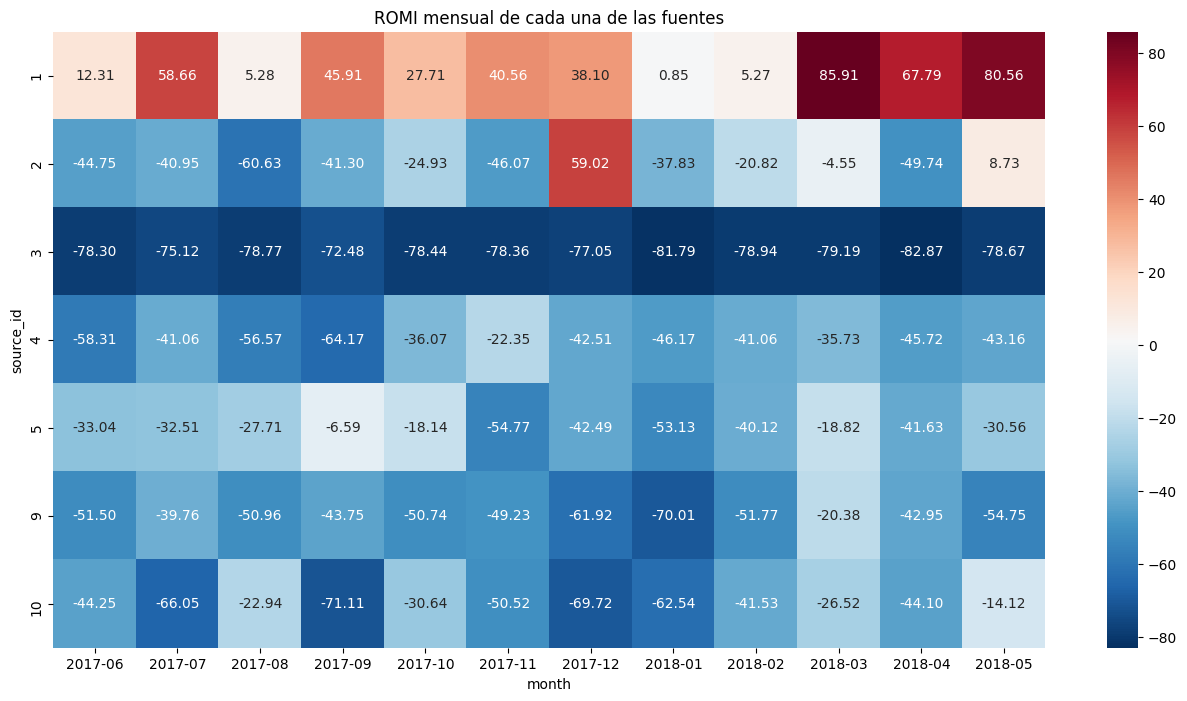

In [229]:
#Heatmap del ROMI de cada una de las fuentes de manera mensual

plt.figure(figsize = (16, 8))
plt.title('ROMI mensual de cada una de las fuentes')

sns.heatmap(
    data=romi_pivot_table,
    annot=True,
    fmt='.2f',
    linecolor='black',
    annot_kws={'size':10},
    cbar=True,
    cmap="RdBu_r"
    
)
plt.show()


In [230]:
#Podemos observar que la fuente 3 de marketing es la que mas esta generando perdidas, al ser la que representa un gasto mayor para la empresa
#Mientras que la feunte numero 1 representa mas rentabilidad

## Calculo de revenue por dispositivo

In [231]:
#Agrupamos el dataframe complete_df añadiendo el dispositivo
orders_devices= complete_df.groupby(['Device','Source Id', 'purchase_month']).agg({'Revenue':'sum'}).reset_index()
orders_devices.columns = ['device','source_id', 'month', 'revenue']
orders_devices.head()

,device,source_id,month,revenue
0,desktop,1,2017-06,1109.72
1,desktop,1,2017-07,1423.58
2,desktop,1,2017-08,829.57
3,desktop,1,2017-09,1966.18
4,desktop,1,2017-10,2338.29


In [232]:
#Cantidad de dispositivos
print(orders_devices['device'].unique())

['desktop' 'touch']


In [233]:
#DataFrame de ordenes provenientes del dispositivo desktop
desktop_device_orders = orders_devices.query('device == "desktop"')
print(desktop_device_orders['device'].unique())

['desktop']


In [234]:
desktop_device_orders.head()

,device,source_id,month,revenue
0,desktop,1,2017-06,1109.72
1,desktop,1,2017-07,1423.58
2,desktop,1,2017-08,829.57
3,desktop,1,2017-09,1966.18
4,desktop,1,2017-10,2338.29


In [235]:
desktop_device_orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 86 entries, 0 to 85
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype    
---  ------     --------------  -----    
 0   device     86 non-null     object   
 1   source_id  86 non-null     int64    
 2   month      86 non-null     period[M]
 3   revenue    86 non-null     float64  
dtypes: float64(1), int64(1), object(1), period[M](1)
memory usage: 3.4+ KB


In [236]:
#Obtendremos una tabla para visualizar el romi del dispositivo desktop en funcion de la fuente de marketing durante el periodo completo
desktop_marketing = desktop_device_orders.pivot_table(
    index='source_id',
    columns='month',
    values='revenue'
)
desktop_marketing


month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06
source_id,,,,,,,,,,,,,
1,1109.72,1423.58,829.57,1966.18,2338.29,2838.53,2831.26,1903.24,1982.68,2688.00,1907.66,2326.57,NaN
2,1248.45,1137.85,589.64,1506.15,3087.17,2019.19,7460.39,2375.17,3167.71,3278.88,1285.88,2529.64,NaN
3,1518.43,1621.56,1135.32,2544.58,3015.35,3263.73,3258.09,2314.65,2546.01,2371.56,1384.71,1671.30,NaN
4,1258.26,1694.94,1082.68,1564.87,3351.76,3427.28,3621.42,2474.23,2690.90,2995.28,2055.87,1882.55,3.42
5,1542.15,1750.56,1403.70,3083.53,4277.06,2558.83,3088.30,2289.68,2723.06,3404.87,1861.82,2272.59,NaN
7,NaN,NaN,1.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,133.74,165.82,99.37,210.58,248.55,300.73,221.24,142.67,231.95,340.26,164.70,134.99,NaN
10,133.24,97.92,165.85,119.21,397.99,320.04,172.15,184.68,245.27,283.76,184.73,294.86,NaN


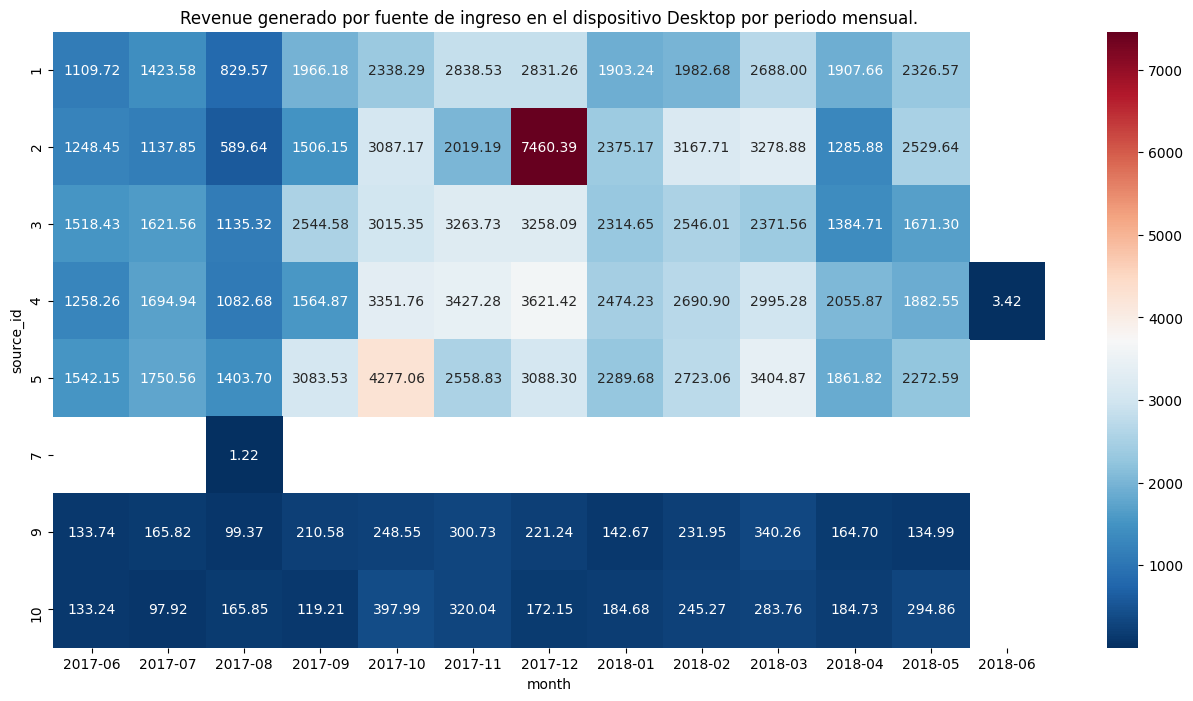

In [237]:
plt.figure(figsize = (16, 8))
plt.title('Revenue generado por fuente de ingreso en el dispositivo Desktop por periodo mensual.')

sns.heatmap(
    data=desktop_marketing,
    annot=True,
    fmt='.2f',
    linecolor='black',
    annot_kws={'size':10},
    cbar=True,
    cmap="RdBu_r"
    
)
plt.show()


In [238]:
#DataFrame de ordenes provenientes del dispositivo touch
touch_device_orders = orders_devices.query('device == "touch"')
print(touch_device_orders['device'].unique())

['touch']


In [239]:
touch_device_orders.head()

,device,source_id,month,revenue
86,touch,1,2017-06,154.47
87,touch,1,2017-07,278.70
88,touch,1,2017-08,172.53
89,touch,1,2017-09,225.34
90,touch,1,2017-10,619.24


In [240]:
touch_device_orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 84 entries, 86 to 169
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype    
---  ------     --------------  -----    
 0   device     84 non-null     object   
 1   source_id  84 non-null     int64    
 2   month      84 non-null     period[M]
 3   revenue    84 non-null     float64  
dtypes: float64(1), int64(1), object(1), period[M](1)
memory usage: 3.3+ KB


In [241]:
#Obtendremos una tabla para visualizar el romi del dispositivo touch en funcion de la fuente de marketing durante el periodo completo
touch_marketing = touch_device_orders.pivot_table(
    index='source_id',
    columns='month',
    values='revenue'
)
touch_marketing

month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05
source_id,,,,,,,,,,,,
1,154.47,278.70,172.53,225.34,619.24,598.43,401.87,301.53,338.06,831.34,319.74,323.38
2,92.69,239.90,123.45,246.31,549.87,811.01,328.35,209.62,375.05,485.02,218.81,394.67
3,159.71,287.76,168.79,197.34,377.68,420.59,465.08,382.35,450.15,350.22,208.16,336.64
4,206.89,385.57,314.71,295.74,753.13,757.04,793.99,665.72,675.86,836.45,337.22,512.98
5,209.68,272.99,175.92,511.93,443.99,302.11,288.71,228.18,313.38,272.38,181.61,275.57
9,4.58,16.44,22.71,23.22,51.64,46.10,29.31,21.44,34.06,42.16,48.39,28.89
10,41.95,14.05,13.36,13.86,37.06,72.01,23.45,45.44,35.91,103.05,32.31,57.12


In [ ]:
plt.figure(figsize = (16, 8))
plt.title('Revenue generado por fuente de ingreso en el dispositivo touch por periodo mensual')

sns.heatmap(
    data=touch_marketing,
    annot=True,
    fmt='.2f',
    linecolor='black',
    annot_kws={'size':10},
    cbar=True,
    cmap="Greens"
    
)
plt.show()

# Conclusión

## Despues de haber calculado el ROMI podemos ver que la fuente número 1 es la mas rentable, seguida de la número 2, mientras que la menos rentable es la fuente número 3
## La fuente que mas costo genera a la empresa es la número 3, necesitando de un revenue mucho mas alto en comparacion al resto de fuentes, de ahi viene su ROMI tan bajo
## En la parte de los dispositivos, el dispositivo desktop genera un revenue mucho mayor, en comparacion al revenue generado por el dispositivo touch.